In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.applications import VGG16, MobileNetV2

Bacterial leaf blight: 40 images
Brown spot: 40 images
Leaf smut: 39 images


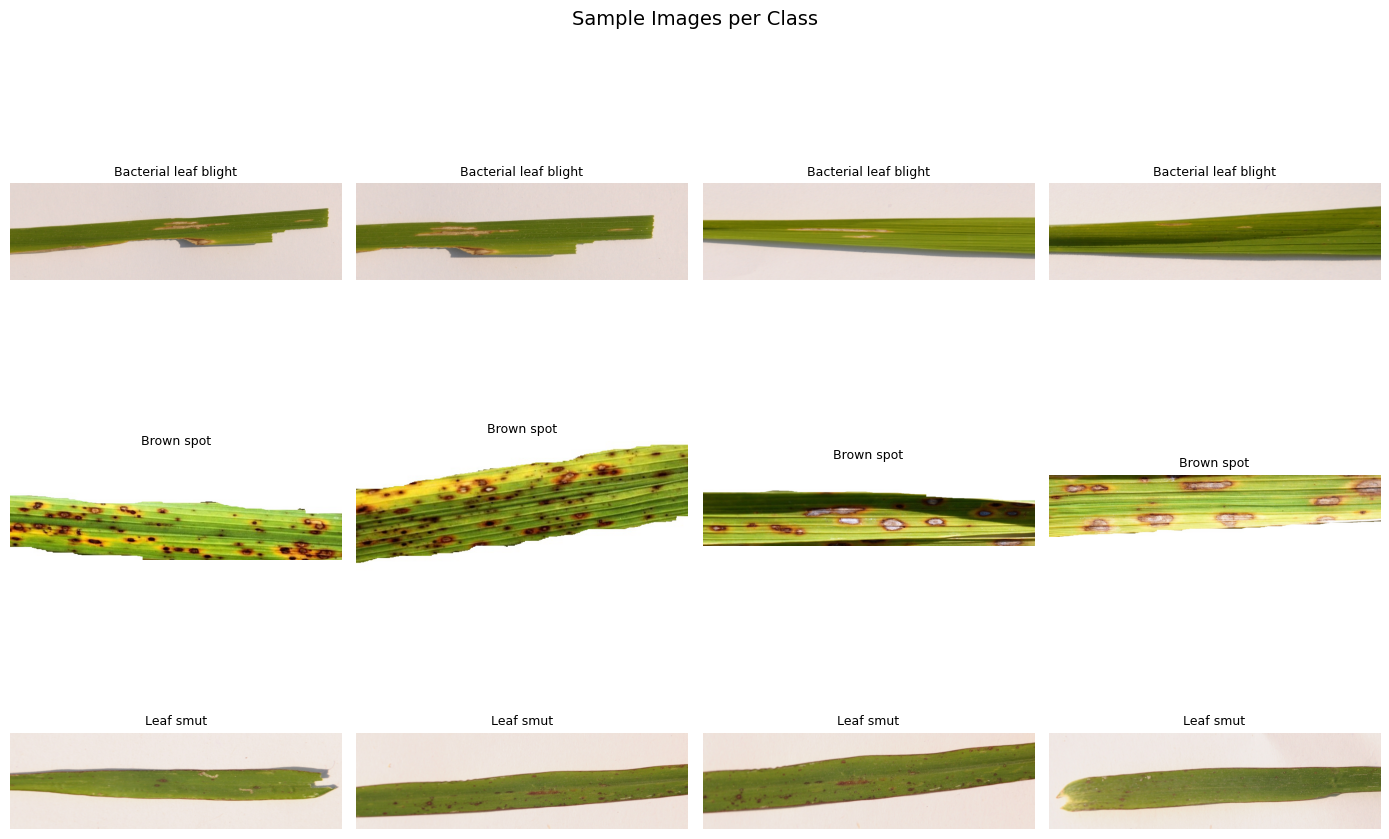

Unique sizes: {(537, 216), (503, 174), (367, 73), (562, 217), (763, 268), (946, 255), (768, 514), (427, 193), (617, 244), (296, 88), (340, 94), (316, 127), (699, 197), (467, 104), (1200, 900), (510, 383), (1504, 323), (286, 92), (311, 170), (948, 233), (359, 168), (766, 250), (765, 224), (250, 200), (565, 233), (614, 409), (741, 291), (301, 71), (456, 124), (376, 80), (1480, 279), (948, 211), (3081, 897), (1530, 371)}


In [5]:
# Set your dataset path — folder structure should be:
# rice_leaf/
#   Leaf smut/
#   Brown spot/
#   Bacterial leaf blight/

DATA_DIR = r"C:\Users\91842\Downloads\PRCP-1001-RiceLeaf\Data"   # update this to your actual folder path

# Check class distribution
for cls in os.listdir(DATA_DIR):
    count = len(os.listdir(os.path.join(DATA_DIR, cls)))
    print(f"{cls}: {count} images")

# Visualise sample images from each class
fig, axes = plt.subplots(3, 4, figsize=(14, 10))
classes = os.listdir(DATA_DIR)

for row, cls in enumerate(classes):
    cls_path = os.path.join(DATA_DIR, cls)
    images = os.listdir(cls_path)[:4]
    for col, img_name in enumerate(images):
        img = plt.imread(os.path.join(cls_path, img_name))
        axes[row, col].imshow(img)
        axes[row, col].set_title(cls, fontsize=9)
        axes[row, col].axis('off')

plt.suptitle("Sample Images per Class", fontsize=14)
plt.tight_layout()
plt.show()

# Check image sizes
from PIL import Image
sizes = []
for cls in os.listdir(DATA_DIR):
    for img_name in os.listdir(os.path.join(DATA_DIR, cls)):
        img = Image.open(os.path.join(DATA_DIR, cls, img_name))
        sizes.append(img.size)
print("Unique sizes:", set(sizes))

Found 96 images belonging to 3 classes.
Found 23 images belonging to 3 classes.
Classes: {'Bacterial leaf blight': 0, 'Brown spot': 1, 'Leaf smut': 2}


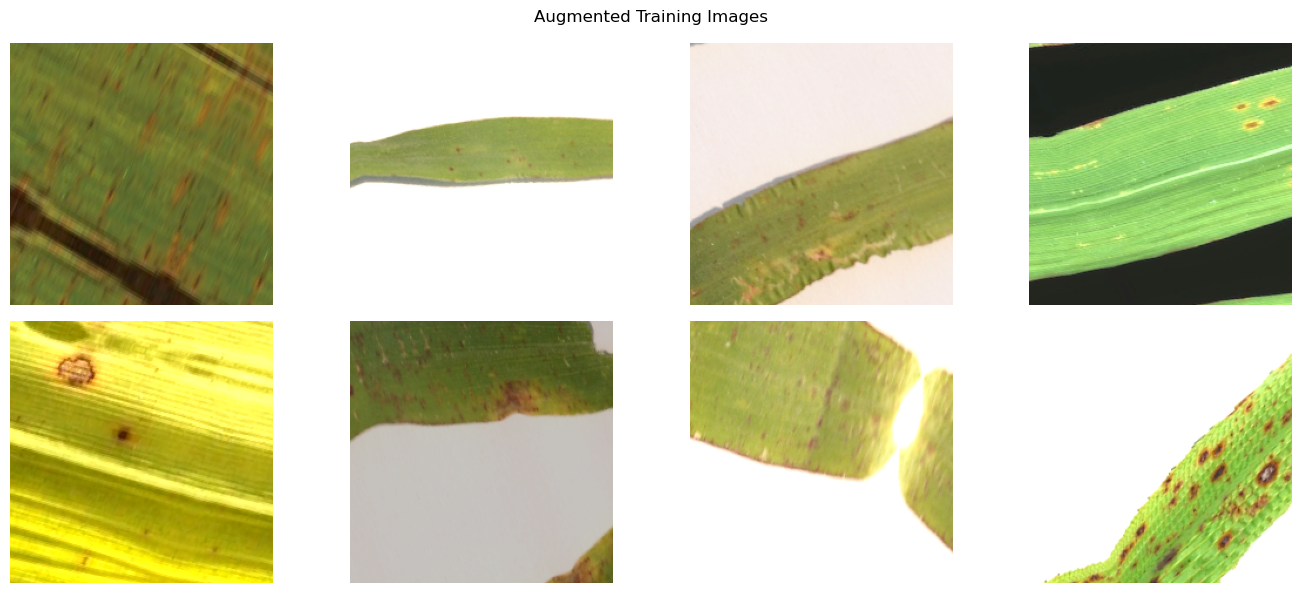

In [16]:
# --- WITHOUT Augmentation ---
datagen_no_aug = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

# --- WITH Augmentation ---
# IMPROVED augmentation — replace your datagen_aug block
datagen_aug = ImageDataGenerator(
    rescale=1./255,
    rotation_range=45,
    width_shift_range=0.3,
    height_shift_range=0.3,
    shear_range=0.3,
    zoom_range=0.3,
    horizontal_flip=True,
    vertical_flip=True,
    brightness_range=[0.6, 1.4],
    channel_shift_range=30.0,   # new
    fill_mode='reflect',         # new
    validation_split=0.2
)

IMG_SIZE = (224, 224)
BATCH_SIZE = 16

train_gen = datagen_aug.flow_from_directory(
    DATA_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='training', seed=42
)

val_gen = datagen_aug.flow_from_directory(
    DATA_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='validation', seed=42
)

print("Classes:", train_gen.class_indices)

# Visualise augmented images
sample_images, _ = next(train_gen)
fig, axes = plt.subplots(2, 4, figsize=(14, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow(sample_images[i])
    ax.axis('off')
plt.suptitle("Augmented Training Images")
plt.tight_layout()
plt.show()

In [17]:
def build_cnn():
    model = Sequential([
        Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
        BatchNormalization(),
        MaxPooling2D(2,2),

        Conv2D(64, (3,3), activation='relu'),
        BatchNormalization(),
        MaxPooling2D(2,2),

        Conv2D(128, (3,3), activation='relu'),
        BatchNormalization(),
        MaxPooling2D(2,2),

        Flatten(),
        Dense(256, activation='relu'),
        Dropout(0.5),
        Dense(3, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

callbacks = [
    EarlyStopping(patience=10, restore_best_weights=True),
    ReduceLROnPlateau(factor=0.5, patience=5)
]

cnn_model = build_cnn()
cnn_model.summary()

history_cnn = cnn_model.fit(
    train_gen, epochs=30,
    validation_data=val_gen,
    callbacks=callbacks
)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │    22,151,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,246,339 (84.86 MB)

 Trainable params: 22,245,891 (84.86 MB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 19s 3s/step - accuracy: 0.4167 - loss: 28.1004 - val_accuracy: 0.3478 - val_loss: 4.2301 - learning_rate: 0.0010
Epoch 2/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step - accuracy: 0.3750 - loss: 37.7836 - val_accuracy: 0.2609 - val_loss: 3.4328 - learning_rate: 0.0010
Epoch 3/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step - accuracy: 0.4271 - loss: 42.8055 - val_accuracy: 0.2609 - val_loss: 3.6318 - learning_rate: 0.0010
Epoch 4/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step - accuracy: 0.3958 - loss: 45.5706 - val_accuracy: 0.3478 - val_loss: 15.6102 - learning_rate: 0.0010
Epoch 5/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.4479 - loss: 44.0034 - val_accuracy: 0.3478 - val_loss: 15.0559 - learning_rate: 0.0010
Epoch 6/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.4479 - loss: 36.0730 - val_accuracy: 0.3478 - val_loss: 15.2795 - learning_rate: 0.0010
Epoch 7/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - accuracy: 0.5000 - loss: 32.8833 - val_accuracy: 0.43

In [18]:
def build_vgg16():
    base = VGG16(weights='imagenet', include_top=False, input_shape=(224,224,3))
    base.trainable = False  # freeze base layers

    x = base.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    out = Dense(3, activation='softmax')(x)

    model = Model(inputs=base.input, outputs=out)
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

vgg_model = build_vgg16()
history_vgg = vgg_model.fit(
    train_gen, epochs=30,
    validation_data=val_gen,
    callbacks=callbacks
)

Epoch 1/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 20s 3s/step - accuracy: 0.3438 - loss: 1.2730 - val_accuracy: 0.5652 - val_loss: 1.0367 - learning_rate: 0.0010
Epoch 2/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 18s 3s/step - accuracy: 0.3125 - loss: 1.1912 - val_accuracy: 0.8261 - val_loss: 0.9332 - learning_rate: 0.0010
Epoch 3/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 18s 3s/step - accuracy: 0.3438 - loss: 1.2406 - val_accuracy: 0.7391 - val_loss: 0.9374 - learning_rate: 0.0010
Epoch 4/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 19s 3s/step - accuracy: 0.4688 - loss: 1.0593 - val_accuracy: 0.7391 - val_loss: 0.8874 - learning_rate: 0.0010
Epoch 5/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 18s 3s/step - accuracy: 0.3333 - loss: 1.1082 - val_accuracy: 0.6087 - val_loss: 0.9483 - learning_rate: 0.0010
Epoch 6/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 18s 3s/step - accuracy: 0.4792 - loss: 1.0360 - val_accuracy: 0.7391 - val_loss: 0.8798 - learning_rate: 0.0010
Epoch 7/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 17s 3s/step - accuracy: 0.4688 - loss: 1.0221 - val_accuracy: 0.7391 - val_l

In [24]:
def build_mobilenet():
    base = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224,224,3))
    base.trainable = False

    x = base.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.4)(x)
    out = Dense(3, activation='softmax')(x)

    model = Model(inputs=base.input, outputs=out)
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

mobilenet_model = build_mobilenet()
# ADD class weights to your existing fit() call
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_gen.classes),
    y=train_gen.classes
)
class_weight_dict = dict(enumerate(class_weights))
print("Class weights:", class_weight_dict)

history_mobilenet = mobilenet_model.fit(
    train_gen,
    epochs=30,
    validation_data=val_gen,
    callbacks=callbacks,
    class_weight=class_weight_dict   # ← only change
)



Class weights: {0: np.float64(1.0), 1: np.float64(1.0), 2: np.float64(1.0)}
Epoch 1/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 19s 2s/step - accuracy: 0.3438 - loss: 1.2816 - val_accuracy: 0.8261 - val_loss: 0.7055 - learning_rate: 0.0010
Epoch 2/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.6354 - loss: 0.7988 - val_accuracy: 0.6957 - val_loss: 0.5300 - learning_rate: 0.0010
Epoch 3/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.7396 - loss: 0.5318 - val_accuracy: 0.9130 - val_loss: 0.3024 - learning_rate: 0.0010
Epoch 4/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.7917 - loss: 0.5685 - val_accuracy: 0.9565 - val_loss: 0.2388 - learning_rate: 0.0010
Epoch 5/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.8542 - loss: 0.3953 - val_accuracy: 0.8696 - val_loss: 0.3879 - learning_rate: 0.0010
Epoch 6/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.8438 - loss: 0.4315 - val_accuracy: 0.7391 - val_loss: 0.5750 - learning_rate: 5.0000e-04
Epoch 7/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 7

Starting Fine-Tuning...
Trainable layers: 4 / 158
Epoch 1/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - accuracy: 0.8958 - loss: 0.2387 - val_accuracy: 0.9130 - val_loss: 0.1082 - learning_rate: 1.0000e-05
Epoch 2/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.9167 - loss: 0.2668 - val_accuracy: 0.9130 - val_loss: 0.1827 - learning_rate: 1.0000e-05
Epoch 3/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.9583 - loss: 0.1585 - val_accuracy: 0.9565 - val_loss: 0.1244 - learning_rate: 1.0000e-05
Epoch 4/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.8750 - loss: 0.2487 - val_accuracy: 0.9130 - val_loss: 0.1580 - learning_rate: 1.0000e-05
Epoch 5/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.9167 - loss: 0.2293 - val_accuracy: 0.9130 - val_loss: 0.3263 - learning_rate: 1.0000e-05
Epoch 6/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.9375 - loss: 0.1998 - val_accuracy: 0.9565 - val_loss: 0.2038 - learning_rate: 1.0000e-05
Epoch 7/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/s

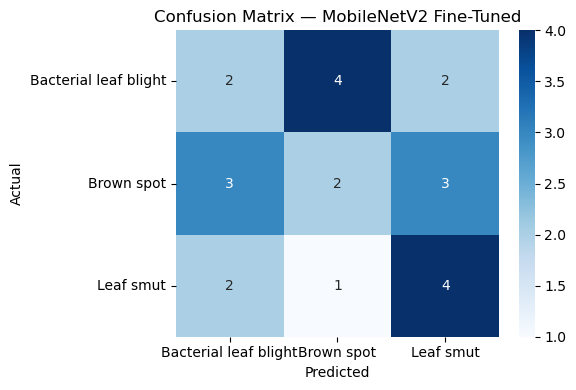

In [20]:
# ── FINE-TUNING: Unfreeze top layers of the already-trained MobileNetV2 ──

print("Starting Fine-Tuning...")

# Unfreeze the entire model first
mobilenet_model.trainable = True

# Re-freeze everything except the last 30 layers
for layer in mobilenet_model.layers[:-30]:
    layer.trainable = False

# Check how many layers are now trainable
trainable = sum(1 for l in mobilenet_model.layers if l.trainable)
print(f"Trainable layers: {trainable} / {len(mobilenet_model.layers)}")

# Recompile with a much lower learning rate
mobilenet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Continue training from where it left off
history_finetune = mobilenet_model.fit(
    train_gen,
    epochs=20,
    validation_data=val_gen,
    callbacks=callbacks
)

# Evaluate the fine-tuned model
evaluate_model(mobilenet_model, val_gen, "MobileNetV2 Fine-Tuned")

2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 264ms/step

  Custom CNN
                       precision    recall  f1-score   support

Bacterial leaf blight       0.00      0.00      0.00         8
           Brown spot       0.50      0.62      0.56         8
            Leaf smut       0.31      0.57      0.40         7

             accuracy                           0.39        23
            macro avg       0.27      0.40      0.32        23
         weighted avg       0.27      0.39      0.31        23



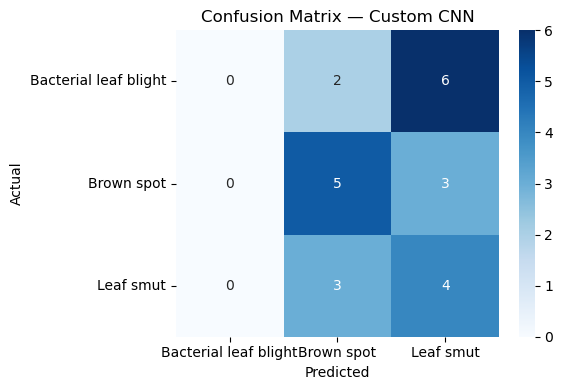

2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 958ms/step

  VGG16 Transfer Learning
                       precision    recall  f1-score   support

Bacterial leaf blight       0.57      0.50      0.53         8
           Brown spot       0.50      0.25      0.33         8
            Leaf smut       0.33      0.57      0.42         7

             accuracy                           0.43        23
            macro avg       0.47      0.44      0.43        23
         weighted avg       0.47      0.43      0.43        23



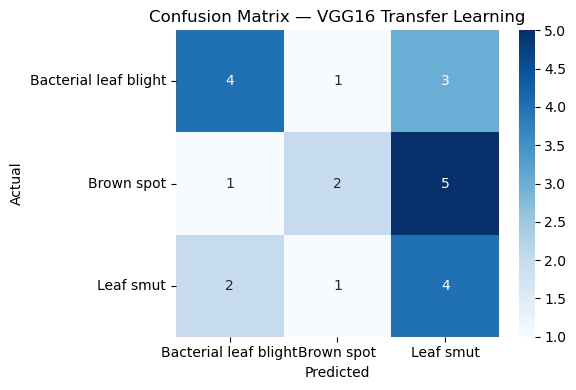

2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 341ms/step

  MobileNetV2 Transfer Learning
                       precision    recall  f1-score   support

Bacterial leaf blight       0.29      0.25      0.27         8
           Brown spot       0.00      0.00      0.00         8
            Leaf smut       0.25      0.29      0.27         7

             accuracy                           0.17        23
            macro avg       0.18      0.18      0.18        23
         weighted avg       0.18      0.17      0.17        23



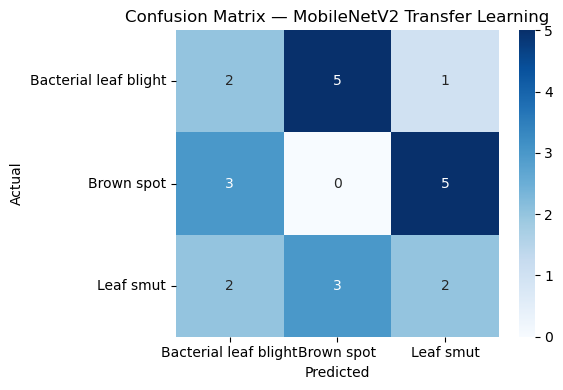

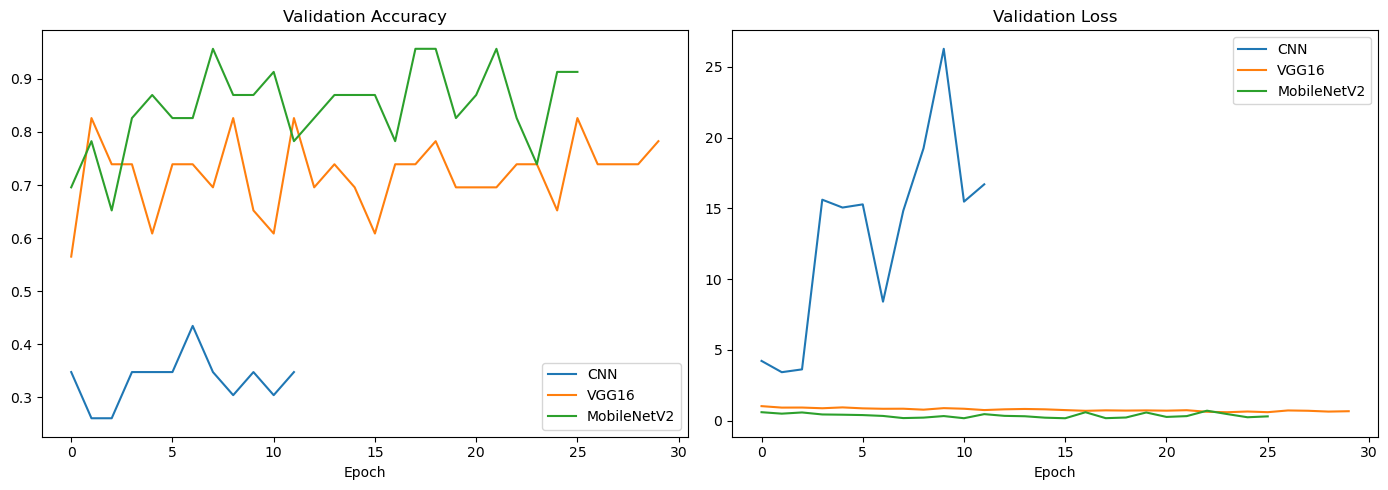

In [21]:
def evaluate_model(model, gen, name):
    gen.reset()
    preds = model.predict(gen)
    y_pred = np.argmax(preds, axis=1)
    y_true = gen.classes
    print(f"\n{'='*40}")
    print(f"  {name}")
    print('='*40)
    print(classification_report(y_true, y_pred, target_names=list(gen.class_indices.keys())))

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=gen.class_indices.keys(),
                yticklabels=gen.class_indices.keys())
    plt.title(f"Confusion Matrix — {name}")
    plt.ylabel("Actual")
    plt.xlabel("Predicted")
    plt.tight_layout()
    plt.show()

evaluate_model(cnn_model, val_gen, "Custom CNN")
evaluate_model(vgg_model, val_gen, "VGG16 Transfer Learning")
evaluate_model(mobilenet_model, val_gen, "MobileNetV2 Transfer Learning")

# Training curves comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for hist, name in [(history_cnn,'CNN'), (history_vgg,'VGG16'), (history_mobilenet,'MobileNetV2')]:
    axes[0].plot(hist.history['val_accuracy'], label=name)
    axes[1].plot(hist.history['val_loss'], label=name)

axes[0].set_title("Validation Accuracy")
axes[1].set_title("Validation Loss")
for ax in axes:
    ax.legend()
    ax.set_xlabel("Epoch")
plt.tight_layout()
plt.show()

Epoch 1/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step - accuracy: 0.4583 - loss: 1.3220 - val_accuracy: 0.7826 - val_loss: 0.5989 - learning_rate: 0.0010
Epoch 2/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.6042 - loss: 0.8732 - val_accuracy: 0.7826 - val_loss: 0.5473 - learning_rate: 0.0010
Epoch 3/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.7708 - loss: 0.6040 - val_accuracy: 0.8696 - val_loss: 0.3653 - learning_rate: 0.0010
Epoch 4/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.7604 - loss: 0.5261 - val_accuracy: 0.6957 - val_loss: 0.4457 - learning_rate: 0.0010
Epoch 5/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.8542 - loss: 0.4611 - val_accuracy: 0.7826 - val_loss: 0.5501 - learning_rate: 0.0010
Epoch 6/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.8021 - loss: 0.4774 - val_accuracy: 0.8261 - val_loss: 0.5433 - learning_rate: 5.0000e-04
Epoch 7/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.8333 - loss: 0.3476 - val_accuracy: 0.7391 - val_los

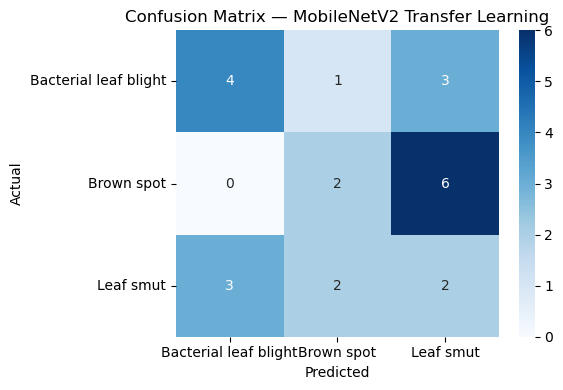

In [22]:
# You already have these:
mobilenet_model = build_mobilenet()
history_mobilenet = mobilenet_model.fit(train_gen, epochs=30, validation_data=val_gen, callbacks=callbacks)
evaluate_model(mobilenet_model, val_gen, "MobileNetV2 Transfer Learning")

In [28]:
# Replace the cv2 loading block with this PIL version — no install needed

from PIL import Image

print("Loading images...")
X, y_labels = [], []
class_names = sorted(os.listdir(DATA_DIR))

for label, cls in enumerate(class_names):
    cls_path = os.path.join(DATA_DIR, cls)
    for img_name in os.listdir(cls_path):
        img_path = os.path.join(cls_path, img_name)
        try:
            img = Image.open(img_path).convert("RGB")
            img = img.resize((224, 224))
            img = np.array(img) / 255.0
            X.append(img)
            y_labels.append(label)
        except Exception as e:
            print(f"Skipping {img_name}: {e}")

X = np.array(X)
y_labels = np.array(y_labels)
print(f"Loaded: {X.shape}, Labels: {y_labels.shape}")
print("Classes:", class_names)

Loading images...
Loaded: (119, 224, 224, 3), Labels: (119,)
Classes: ['Bacterial leaf blight', 'Brown spot', 'Leaf smut']


In [27]:
import subprocess
subprocess.run(["pip", "install", "opencv-python"], check=True)

CompletedProcess(args=['pip', 'install', 'opencv-python'], returncode=0)